# Notebook 30 — Domain-Robustness Experiments (3-Dataset VPN Detection)

## Methodological Framework

### Problem
Three datasets with **heterogeneous feature provenance**:
- **ISCX / VNAT**: PCAP-based processing via `extract_features_from_flows()`
- **USBVPN**: JSON-based processing via `_calculate_flow_stats_from_packets()`

When `load_and_prepare_data()` concatenates them, columns present in one dataset
but absent in another become NaN, then get `fillna(0.0)` — the model can trivially
learn "zero = structurally absent = this dataset" → **dataset-identity leakage**.

### Rule
> **Never use a feature whose value for an entire dataset is an imputation artifact.**
> The only defensible strategy is **strict feature intersection**: use only features
> computed identically and semantically equivalently across all three datasets.

### Experiments
| ID | Experiment | Hypothesis |
|----|-----------|------------|
| Diag | Domain fingerprinting | Quantify feature-level dataset leakage |
| A | Drop direction features | Remove the 2 strongest domain fingerprints |
| B | Dataset-balanced sampling | Cap USBVPN training to match ISCX+VNAT |
| C | Combined (A + B) | Both mitigations together |
| D | IAT feature reconstruction | Re-extract VNAT IAT from raw PCAP (not imputation) |
| E | Adversarial feature selection | Iteratively remove leaky features |

### What is NOT valid
- Zero-filling structurally missing features
- Claiming "3DS beats 2DS" without matching session-level deployment metrics
- Flow-AUC alone without block recall, block FPR, session AUC


In [1]:
# ── Cell 0: Imports & Config ────────────────────────────────────────────
%matplotlib inline

import sys, os, json, warnings, time
warnings.filterwarnings('ignore')

_root = os.path.abspath(os.path.join(os.getcwd(), '..')) \
    if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.feature_pipeline import (
    FeaturePipeline, COMPACT_FEATURES, DIRECTION_FEATURES,
)
from src.features.extract import extract_features_from_flows, load_feature_config
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.optimization.dataset_adversarial_feature_selection import train_dataset_detector
from src.eval.session_metrics import aggregate_to_session, session_metrics

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

paths = load_paths()
logger = setup_logger(level='INFO')
SEED = 42
EXPERIMENTS_DIR = paths.artifacts_dir / 'experiments'
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)


## Section 0 — Build Clean 3-Dataset Pool (Strict Feature Intersection)

**Key methodological step**: Instead of `load_and_prepare_data()` which calls
`fillna(0.0)` on structurally missing columns (line 257 of `data_preparation.py`),
we load each dataset separately and keep **only columns present in ALL three**.

This guarantees no feature value is an imputation artifact.


In [2]:
# ── Cell 1: Load each dataset, compute strict intersection ──────────────

cfg = load_feature_config(paths.configs_dir / 'features.yaml')

# 1a. VNAT
vnat_feats = pd.read_parquet(paths.data_processed_dir / 'vnat' / 'features.parquet')
vnat_feats['dataset'] = 'vnat'
print(f'VNAT features.parquet: {vnat_feats.shape}  cols={sorted(vnat_feats.columns.tolist())}')

# 1b. ISCX
iscx_feats = pd.read_parquet(paths.data_processed_dir / 'iscx' / 'features.parquet')
iscx_feats['dataset'] = 'iscx'
print(f'ISCX features.parquet: {iscx_feats.shape}  cols={sorted(iscx_feats.columns.tolist())}')

# 1c. USBVPN
usbvpn_feats = pd.read_parquet(paths.data_processed_dir / 'usbvpn' / 'flows.parquet')
usbvpn_feats['dataset'] = 'usbvpn'
print(f'USBVPN flows.parquet:  {usbvpn_feats.shape}  cols={sorted(usbvpn_feats.columns.tolist())}')

# ── Strict intersection ──
META = {'flow_id','capture_id','label','dataset','split',
        'source_file','source_capture_id','q_packet_count','q_min_packets_ok',
        'app','connection_str','file_names'}

v_feat = set(vnat_feats.columns) - META
i_feat = set(iscx_feats.columns) - META
u_feat = set(usbvpn_feats.columns) - META

INTERSECTION = sorted(v_feat & i_feat & u_feat)
print(f'\nSTRICT FEATURE INTERSECTION ({len(INTERSECTION)}):')
for f in INTERSECTION:
    print(f'  {f}')

shared_not_vnat = sorted((i_feat & u_feat) - v_feat)
print(f'\nISCX+USBVPN shared but MISSING in VNAT (would leak if zero-filled):')
for f in shared_not_vnat:
    print(f'  {f}')


VNAT features.parquet: (33711, 16)  cols=['capture_id', 'dataset', 'direction_balance_bytes', 'direction_balance_packets', 'dispersion_symmetry', 'flow_id', 'label', 'q_min_packets_ok', 'q_packet_count', 'source_capture_id', 'source_file', 'split', 'sz_coef_variation', 'sz_iqr_norm_median', 'sz_p25_median_ratio', 'sz_p75_median_ratio']
ISCX features.parquet: (76687, 29)  cols=['app', 'capture_id', 'connection_str', 'dataset', 'direction_balance_bytes', 'direction_balance_packets', 'dispersion_symmetry', 'flow_id', 'iat_all_mean', 'iat_all_median', 'iat_all_p25', 'iat_all_p75', 'iat_all_std', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'label', 'q_min_packets_ok', 'q_packet_count', 'split', 'sz_coef_variation', 'sz_iqr_norm_median', 'sz_mean_max', 'sz_mean_min', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_std_max', 'sz_std_min']
USBVPN flows.parquet:  (58977, 39)  cols=['bytes_down', 'bytes_up', 'capture_id', 'dataset', 'direction_balance_bytes', 'direction_balan

In [3]:
# ── Cell 2: Assemble clean pool ─────────────────────────────────────────

keep = sorted(META & set(vnat_feats.columns) & set(iscx_feats.columns) & set(usbvpn_feats.columns))
keep = keep + INTERSECTION

def safe_sel(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

df_all = pd.concat([safe_sel(vnat_feats, keep),
                    safe_sel(iscx_feats, keep),
                    safe_sel(usbvpn_feats, keep)], ignore_index=True)

# FeaturePipeline.fit() requires ID_COLS = [flow_id, capture_id, source_file, source_capture_id]
# These are schema/metadata columns excluded from training (FORBIDDEN_COLS / EXCLUDE_FROM_MODEL).
# Filling with empty strings is safe — this is NOT zero-filling a feature.
for id_col in ['source_file', 'source_capture_id']:
    if id_col not in df_all.columns:
        df_all[id_col] = ''

if 'q_min_packets_ok' in df_all.columns:
    before = len(df_all)
    df_all = df_all[df_all['q_min_packets_ok'].fillna(1) == 1].copy()
    print(f'q_min_packets_ok filter: {before} -> {len(df_all)}')

# Validate NO structural NaN in intersection features
for c in INTERSECTION:
    for ds in ['vnat','iscx','usbvpn']:
        n = df_all[df_all['dataset']==ds][c].isna().sum()
        if n > 0:
            print(f'  WARNING: {c} has {n} NaN in {ds}')
df_all[INTERSECTION] = df_all[INTERSECTION].fillna(0.0)

df_all['split'] = df_all['split'].astype(str)
df_all['dataset'] = df_all['dataset'].astype(str)
df_all['label'] = df_all['label'].astype(int)
for c in INTERSECTION:
    df_all[c] = pd.to_numeric(df_all[c], errors='coerce').fillna(0.0).astype(float)

print(f'\nClean pool: {df_all.shape}')
print(pd.crosstab(df_all['split'], df_all['dataset']))
print()
print(pd.crosstab(df_all['dataset'], df_all['label'], margins=True))

tc = df_all[df_all['split']=='train']['dataset'].value_counts()
print(f'\nTraining composition:')
for ds, n in tc.items():
    print(f'  {ds}: {n:,} ({100*n/tc.sum():.1f}%)')

compact_ok = [c for c in COMPACT_FEATURES if c in INTERSECTION]
print(f'\nCOMPACT_FEATURES in intersection: {compact_ok} ({len(compact_ok)}/7)')


q_min_packets_ok filter: 169375 -> 72612

Clean pool: (72612, 16)
dataset  iscx  usbvpn  vnat
split                      
test     1283    6843   607
train    8291   39232  7334
val      2227    6629   166

label        0      1    All
dataset                     
iscx      8858   2943  11801
usbvpn   44248   8456  52704
vnat      7733    374   8107
All      60839  11773  72612

Training composition:
  usbvpn: 39,232 (71.5%)
  iscx: 8,291 (15.1%)
  vnat: 7,334 (13.4%)

COMPACT_FEATURES in intersection: ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets'] (7/7)


In [4]:
# ── Cell 3: Hyperparameters ─────────────────────────────────────────────

with open(paths.artifacts_dir / 'optuna_xgboost_firewall_best_params.json') as f:
    xgb_params = json.load(f)
xgb_params.update({'objective':'binary:logistic','eval_metric':'logloss',
    'booster':'gbtree','tree_method':'hist',
    'n_estimators':1000,'random_state':SEED,'n_jobs':1,'early_stopping_rounds':50})

with open(paths.artifacts_dir / 'optuna_catboost_firewall_best_params.json') as f:
    cat_params = json.load(f)
cat_params.update({'iterations':1000,'random_seed':SEED,'thread_count':1,
    'verbose':False,'allow_writing_files':False,'early_stopping_rounds':150})

with open(paths.artifacts_dir / 'optuna_lgbm_firewall_best_params.json') as f:
    lgbm_params = json.load(f)
lgbm_params.update({'objective':'binary','metric':'binary_logloss',
    'boosting_type':'gbdt','n_estimators':1000,'verbose':-1,'random_state':SEED,'n_jobs':1})

print('Hyperparameters loaded (Optuna-tuned, same as NB29).')


Hyperparameters loaded (Optuna-tuned, same as NB29).


In [5]:
# ── Cell 4: Experiment helper with session-level eval ───────────────────

def _session_eval(pred_csv, split='test'):
    '''Compute session-level deployment metrics from a predictions CSV.'''
    preds = pd.read_csv(pred_csv)
    t = preds[preds['split'] == split].copy()
    if len(t) == 0:
        return {}
    pc = 'prob_iso' if 'prob_iso' in t.columns else 'prob'
    sess = aggregate_to_session(t, prob_col=pc, label_col='label',
                                session_col='capture_id', rule='weighted_top5_mean')
    return session_metrics(sess, prob_col=pc, label_col='label')


def _session_eval_dataset(pred_csv, ds, split='test'):
    '''Session metrics for a single dataset subset.'''
    preds = pd.read_csv(pred_csv)
    t = preds[(preds['split'] == split) & (preds['dataset'] == ds)].copy()
    if len(t) == 0 or t['label'].nunique() < 2:
        return {}
    pc = 'prob_iso' if 'prob_iso' in t.columns else 'prob'
    sess = aggregate_to_session(t, prob_col=pc, label_col='label',
                                session_col='capture_id', rule='weighted_top5_mean')
    return session_metrics(sess, prob_col=pc, label_col='label')


def run_experiment(name, df_pool, feature_cols, output_subdir,
                   *, skip_pipeline_transform=False):
    '''Train balanced-bagging ensemble; return summary dict with session metrics.'''
    out_dir = EXPERIMENTS_DIR / output_subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()

    print(f'\n{"="*72}')
    print(f'  EXPERIMENT: {name}')
    print(f'  Features ({len(feature_cols)}): {feature_cols}')
    ds_tc = df_pool[df_pool["split"]=="train"]["dataset"].value_counts()
    print(f'  Train: {ds_tc.to_dict()} ({ds_tc.sum():,} total)')
    print(f'{"="*72}')

    if not skip_pipeline_transform:
        pipe = FeaturePipeline().fit(df_pool[df_pool['split']=='train'].copy())
        df_t = pipe.transform(df_pool)
        for col in ['label','split','capture_id','dataset','flow_id',
                     'source_file','source_capture_id']:
            if col in df_pool.columns:
                df_t[col] = df_pool[col].values
        mcols = [c for c in pipe.model_feature_names() if c in feature_cols]
    else:
        df_t = df_pool.copy()
        mcols = feature_cols

    missing = [c for c in mcols if c not in df_t.columns]
    if missing:
        raise ValueError(f'Missing: {missing}')

    results = run_balanced_bagging(
        df=df_t, label_col='label', group_col='capture_id',
        dataset_col='dataset', split_col='split',
        bags_per_family=3, majority_ratio=1.0,
        target_fprs='0.0,0.001,0.005,0.01', seed=SEED,
        output_dir=str(out_dir), model_types=['xgb','lgbm','cat'],
        feature_cols=mcols,
        weight_xgb=1.0, weight_lgbm=1.0, weight_cat=1.0,
        xgb_params=xgb_params, cat_params=cat_params, lgbm_params=lgbm_params)

    elapsed = time.time() - t0

    def sm(sec, key, met):
        try: return results[sec][key][met]
        except (KeyError, TypeError): return float('nan')

    s = {
        'experiment': name,
        'n_features': len(mcols), 'features': mcols,
        'train_flows': int((df_pool['split']=='train').sum()),
        'val_auc': sm('isotonic','val','auc'),
        'test_auc': sm('isotonic','test_overall','auc'),
        'test_pr_auc': sm('isotonic','test_overall','pr_auc'),
        'elapsed_s': elapsed,
    }
    for ds in ['iscx','vnat','usbvpn']:
        s[f'test_auc_{ds}'] = sm('isotonic', f'test_{ds}', 'auc')
        s[f'test_pr_auc_{ds}'] = sm('isotonic', f'test_{ds}', 'pr_auc')

    # ── Session-level deployment metrics ──
    pred_csv = out_dir / 'predictions.csv'
    if pred_csv.exists():
        sess = _session_eval(pred_csv)
        s['session_roc_auc'] = sess.get('session_roc_auc', float('nan'))
        s['block_recall'] = sess.get('block_recall_at_zero_fp', float('nan'))
        s['block_threshold'] = sess.get('block_threshold', float('nan'))
        for ds in ['iscx','vnat','usbvpn']:
            ds_sess = _session_eval_dataset(pred_csv, ds)
            s[f'session_auc_{ds}'] = ds_sess.get('session_roc_auc', float('nan'))
            s[f'block_recall_{ds}'] = ds_sess.get('block_recall_at_zero_fp', float('nan'))

    with open(out_dir / 'experiment_summary.json', 'w') as f:
        json.dump(s, f, indent=2, default=str)

    print(f'\n  {name}: {elapsed:.0f}s')
    print(f'    Flow  — val AUC={s["val_auc"]:.4f}  test AUC={s["test_auc"]:.4f}')
    sa = s.get('session_roc_auc', float('nan'))
    br = s.get('block_recall', float('nan'))
    print(f'    Session — AUC={sa:.4f}  block_recall@FPR=0={br:.4f}')
    for ds in ['iscx','vnat','usbvpn']:
        print(f'    [{ds:>6s}] flow={s.get(f"test_auc_{ds}",0):.4f}  '
              f'sess={s.get(f"session_auc_{ds}",0):.4f}  '
              f'block_recall={s.get(f"block_recall_{ds}",0):.4f}')
    return s

all_summaries = []


## Section 1 — Domain Fingerprinting Diagnostic

Train XGBoost multiclass to predict dataset from features.
If AUC ≈ 1.0, those features encode dataset identity.


In [6]:
# ── Cell 5: Domain fingerprinting ───────────────────────────────────────

df_train = df_all[df_all['split']=='train'].copy()
df_val   = df_all[df_all['split']=='val'].copy()

le = LabelEncoder(); le.fit(df_all['dataset'])
y_tr_ds = le.transform(df_train['dataset'])
y_va_ds = le.transform(df_val['dataset'])

ALL_COMPACT = [c for c in COMPACT_FEATURES if c in df_train.columns]
NO_DIR      = [c for c in ALL_COMPACT if c not in DIRECTION_FEATURES]
DIR_ONLY    = [c for c in ALL_COMPACT if c in DIRECTION_FEATURES]

diag_results, diag_models = [], {}
for nm, feats in [('All 7 compact', ALL_COMPACT),
                  ('5 (no direction)', NO_DIR),
                  ('2 (direction only)', DIR_ONLY)]:
    m, auc = train_dataset_detector(
        df_train[feats].values, y_tr_ds, df_val[feats].values, y_va_ds)
    diag_results.append({'Feature Set':nm, 'N':len(feats), 'Domain AUC':auc})
    diag_models[nm] = m
    print(f'  {nm:25s} -> domain AUC = {auc:.4f}')

print()
print(pd.DataFrame(diag_results).to_string(index=False))


  All 7 compact             -> domain AUC = 0.9999
  5 (no direction)          -> domain AUC = 0.9769
  2 (direction only)        -> domain AUC = 0.9972

       Feature Set  N  Domain AUC
     All 7 compact  7    0.999875
  5 (no direction)  5    0.976871
2 (direction only)  2    0.997193


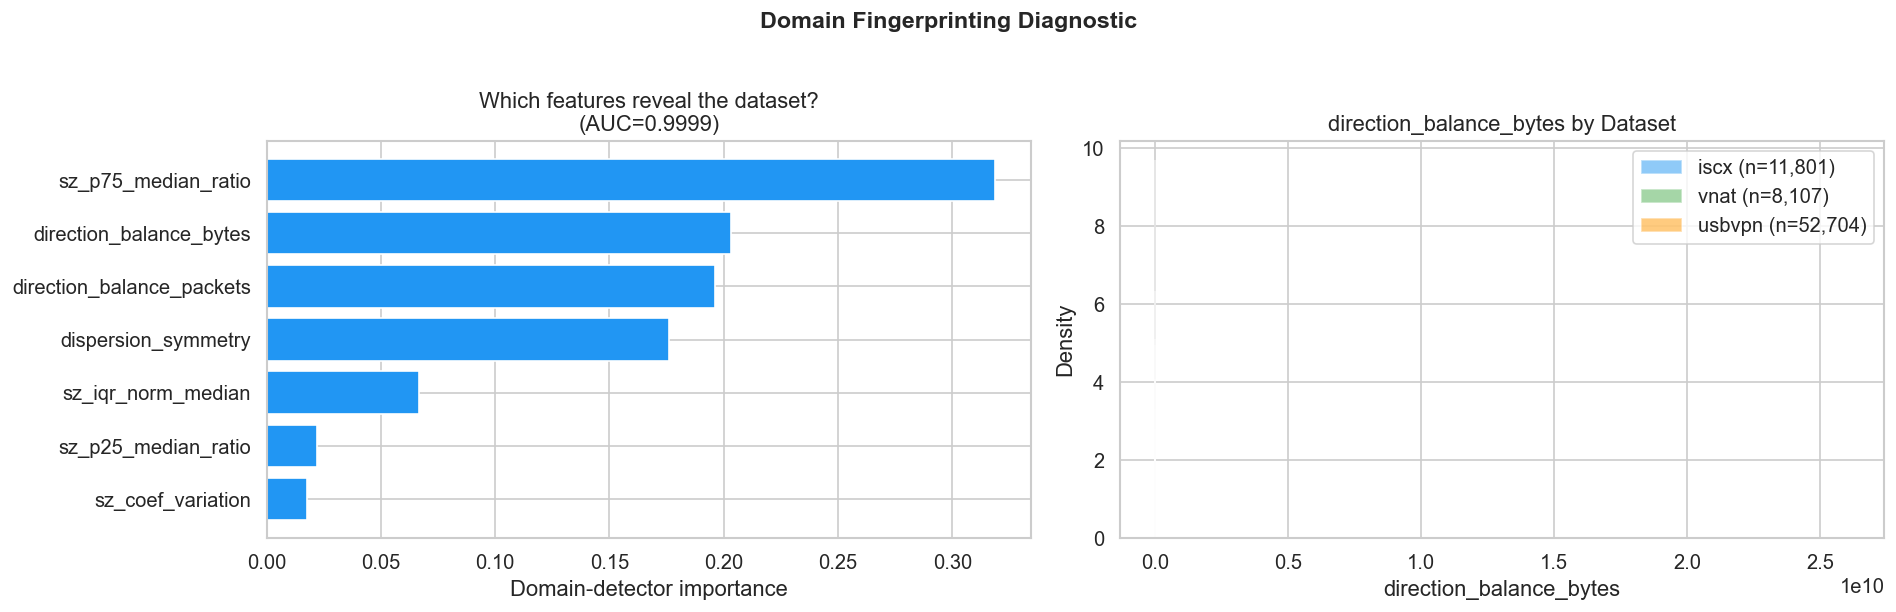

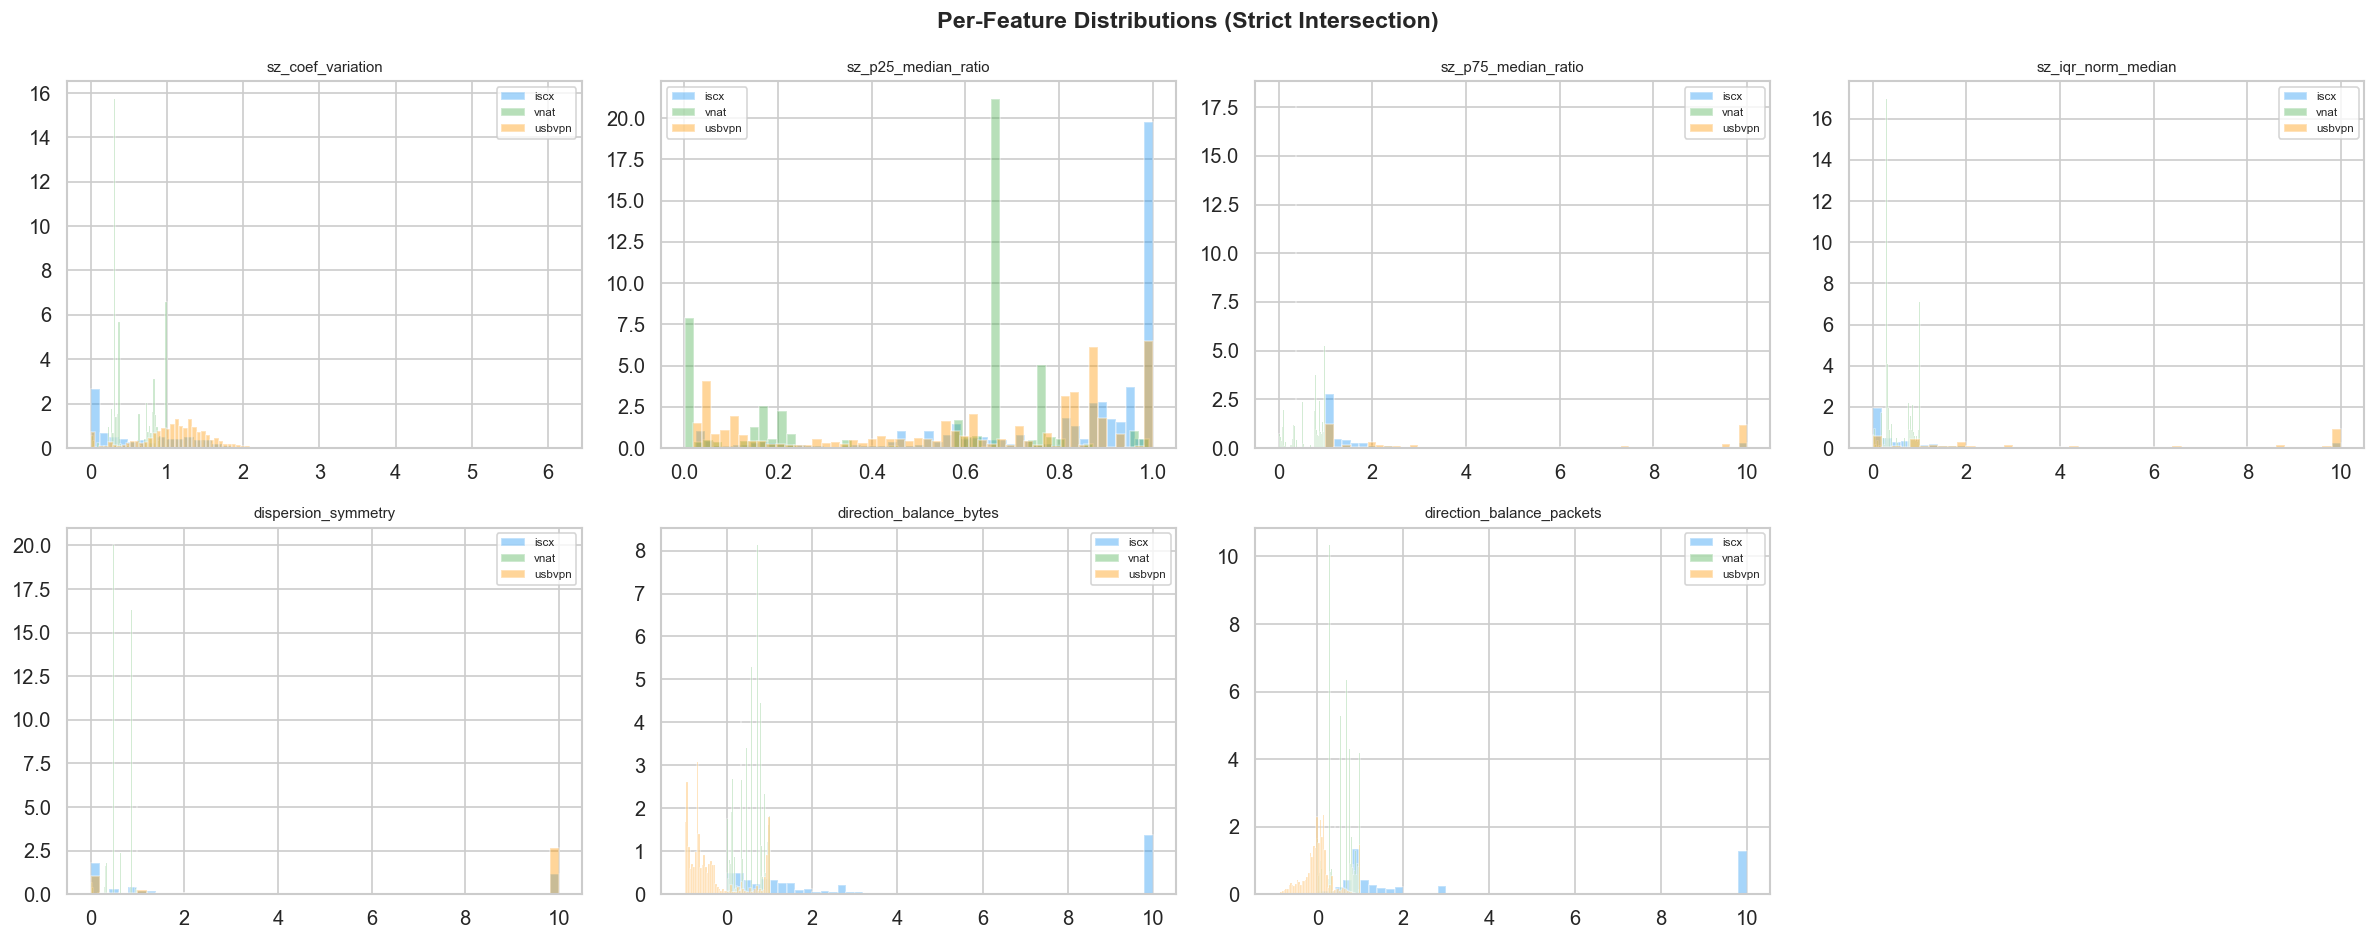

In [7]:
# ── Cell 6: Domain diagnostic plots ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
imp = diag_models['All 7 compact'].feature_importances_
order = np.argsort(imp)
ax.barh([ALL_COMPACT[i] for i in order], imp[order], color='#2196F3')
ax.set_xlabel('Domain-detector importance')
ax.set_title(f'Which features reveal the dataset?\n(AUC={diag_results[0]["Domain AUC"]:.4f})')

ax = axes[1]
for ds, col in [('iscx','#2196F3'),('vnat','#4CAF50'),('usbvpn','#FF9800')]:
    v = df_all[df_all['dataset']==ds]['direction_balance_bytes']
    ax.hist(v, bins=60, alpha=.5, density=True, label=f'{ds} (n={len(v):,})', color=col)
ax.set_xlabel('direction_balance_bytes'); ax.set_ylabel('Density')
ax.set_title('direction_balance_bytes by Dataset'); ax.legend()

plt.suptitle('Domain Fingerprinting Diagnostic', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'diag_domain_fingerprinting.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, feat in enumerate(ALL_COMPACT):
    ax = axes.ravel()[i]
    for ds, col in [('iscx','#2196F3'),('vnat','#4CAF50'),('usbvpn','#FF9800')]:
        ax.hist(df_all[df_all['dataset']==ds][feat].clip(-10,10),
                bins=50, alpha=.4, density=True, color=col, label=ds)
    ax.set_title(feat, fontsize=9); ax.legend(fontsize=7)
axes.ravel()[-1].set_visible(False)
plt.suptitle('Per-Feature Distributions (Strict Intersection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'diag_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 2 — Baselines (Strict Intersection Features)


In [8]:
# ── Cell 7: Baseline A — 2-dataset (ISCX+VNAT) ─────────────────────────

df_2ds = df_all[df_all['dataset'] != 'usbvpn'].copy()
print(f'2-dataset pool: {len(df_2ds):,}')
s_2ds = run_experiment('Baseline: 2DS (ISCX+VNAT)', df_2ds,
                       list(COMPACT_FEATURES), 'baseline_2ds')
all_summaries.append(s_2ds)


2-dataset pool: 19,908

  EXPERIMENT: Baseline: 2DS (ISCX+VNAT)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Train: {'iscx': 8291, 'vnat': 7334} (15,625 total)

  Baseline: 2DS (ISCX+VNAT): 2s
    Flow  — val AUC=0.5494  test AUC=0.7992
    Session — AUC=0.3470  block_recall@FPR=0=0.1875
    [  iscx] flow=0.7288  sess=0.5588  block_recall=1.0000
    [  vnat] flow=0.9491  sess=0.5982  block_recall=0.0714
    [usbvpn] flow=nan  sess=nan  block_recall=nan


In [9]:
# ── Cell 8: Baseline B — 3-dataset (all, 7 features) ───────────────────

s_3ds = run_experiment('Baseline: 3DS (ALL, 7 feats)', df_all,
                       list(COMPACT_FEATURES), 'baseline_3ds')
all_summaries.append(s_3ds)



  EXPERIMENT: Baseline: 3DS (ALL, 7 feats)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Train: {'usbvpn': 39232, 'iscx': 8291, 'vnat': 7334} (54,857 total)

  Baseline: 3DS (ALL, 7 feats): 15s
    Flow  — val AUC=0.9711  test AUC=0.9761
    Session — AUC=0.9854  block_recall@FPR=0=0.0556
    [  iscx] flow=0.8403  sess=0.8824  block_recall=0.0000
    [  vnat] flow=0.9998  sess=1.0000  block_recall=1.0000
    [usbvpn] flow=0.9826  sess=1.0000  block_recall=1.0000


## Section 3 — Experiment A: Drop Direction Features (5 feats, 3DS)


In [10]:
# ── Cell 9: Experiment A ────────────────────────────────────────────────

FEATS_NO_DIR = [c for c in COMPACT_FEATURES if c not in DIRECTION_FEATURES]
print(f'Features: {FEATS_NO_DIR}')
s_a = run_experiment('A: No direction (5f)', df_all, FEATS_NO_DIR, 'exp_a_no_direction')
all_summaries.append(s_a)


Features: ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']

  EXPERIMENT: A: No direction (5f)
  Features (5): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']
  Train: {'usbvpn': 39232, 'iscx': 8291, 'vnat': 7334} (54,857 total)

  A: No direction (5f): 13s
    Flow  — val AUC=0.9398  test AUC=0.9744
    Session — AUC=0.9604  block_recall@FPR=0=0.0556
    [  iscx] flow=0.7842  sess=0.6471  block_recall=0.0000
    [  vnat] flow=0.9927  sess=1.0000  block_recall=1.0000
    [usbvpn] flow=0.9953  sess=1.0000  block_recall=1.0000


## Section 4 — Experiment B: Dataset-Balanced Sampling

Downsample USBVPN **training** to match ISCX+VNAT size.
Val/test untouched. Group-aware (keeps all flows within a capture).


In [11]:
# ── Cell 10: balance_training_pool + Experiment B ───────────────────────

def balance_training_pool(df, seed=42):
    '''Downsample USBVPN train to match ISCX+VNAT train size.'''
    train = df['split'] == 'train'
    non_usb = df[train & (df['dataset'] != 'usbvpn')]
    usb     = df[train & (df['dataset'] == 'usbvpn')]
    rest    = df[~train]
    target = len(non_usb)
    print(f'  ISCX+VNAT train: {target:,}  |  USBVPN train: {len(usb):,}')
    if len(usb) <= target:
        return df
    rng = np.random.RandomState(seed)
    caps = usb.groupby('capture_id').agg(n=('flow_id','count'),lbl=('label','max')).reset_index()
    vpn_caps = caps[caps['lbl']==1]['capture_id'].tolist()
    ben_caps = caps[caps['lbl']==0]['capture_id'].tolist()
    rng.shuffle(ben_caps)
    sel = vpn_caps.copy()
    budget = target - len(usb[usb['capture_id'].isin(vpn_caps)])
    for cap in ben_caps:
        if budget <= 0: break
        sel.append(cap)
        budget -= len(usb[usb['capture_id']==cap])
    usb_s = usb[usb['capture_id'].isin(sel)]
    print(f'  USBVPN after: {len(usb_s):,} ({len(sel)} captures)')
    out = pd.concat([non_usb, usb_s, rest], ignore_index=True)
    print(f'  Balanced total: {len(out):,}')
    return out

df_balanced = balance_training_pool(df_all)
s_b = run_experiment('B: Balanced (7f)', df_balanced, list(COMPACT_FEATURES), 'exp_b_balanced')
all_summaries.append(s_b)


  ISCX+VNAT train: 15,625  |  USBVPN train: 39,232
  USBVPN after: 15,681 (90 captures)
  Balanced total: 49,061

  EXPERIMENT: B: Balanced (7f)
  Features (7): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']
  Train: {'usbvpn': 15681, 'iscx': 8291, 'vnat': 7334} (31,306 total)

  B: Balanced (7f): 24s
    Flow  — val AUC=0.9844  test AUC=0.9885
    Session — AUC=0.9744  block_recall@FPR=0=0.1111
    [  iscx] flow=0.8818  sess=0.8235  block_recall=0.5000
    [  vnat] flow=0.9999  sess=1.0000  block_recall=1.0000
    [usbvpn] flow=0.9951  sess=1.0000  block_recall=1.0000


## Section 5 — Experiment C: Combined (No Direction + Balanced)


In [12]:
# ── Cell 11: Experiment C ───────────────────────────────────────────────

s_c = run_experiment('C: No dir + balanced (5f)', df_balanced,
                     FEATS_NO_DIR, 'exp_c_combined')
all_summaries.append(s_c)



  EXPERIMENT: C: No dir + balanced (5f)
  Features (5): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry']
  Train: {'usbvpn': 15681, 'iscx': 8291, 'vnat': 7334} (31,306 total)

  C: No dir + balanced (5f): 23s
    Flow  — val AUC=0.9665  test AUC=0.9780
    Session — AUC=0.9879  block_recall@FPR=0=0.0556
    [  iscx] flow=0.8540  sess=0.7941  block_recall=0.0000
    [  vnat] flow=1.0000  sess=1.0000  block_recall=1.0000
    [usbvpn] flow=0.9919  sess=1.0000  block_recall=1.0000


## Section 6 — Experiment D: IAT Feature Reconstruction

**Not imputation** — re-extract `iat_all_mean/std/median` from raw VNAT PCAP flows.
ISCX and USBVPN already have these. This computes the *same statistic from source data*,
which is methodologically safe.

Direction features are excluded. Balanced sampling applied.


In [13]:
# ── Cell 12: Re-extract VNAT IAT, build expanded pool ──────────────────

IAT_FEATURES = ['iat_all_mean', 'iat_all_std', 'iat_all_median']
EXPANDED = FEATS_NO_DIR + IAT_FEATURES
print(f'Expanded features ({len(EXPANDED)}): {EXPANDED}')

# Re-extract VNAT
print('\nRe-extracting VNAT with IAT...')
vnat_flows = pd.read_parquet(paths.data_processed_dir / 'vnat' / 'flows.parquet')
vnat_full = extract_features_from_flows(vnat_flows, cfg)
print(f'  VNAT re-extracted: {vnat_full.shape}')

# Build expanded pool
df_exp = df_all.copy()
for c in IAT_FEATURES:
    df_exp[c] = np.nan

# Fill from source data (not imputation).
# Use merge instead of map — USBVPN has duplicate flow_ids across captures
# (e.g. 'mail_0' appears in 7 different captures), so set_index fails.
# We merge on BOTH flow_id + capture_id to get exact row matches.
for ds, src_df in [('vnat', vnat_full), ('iscx', iscx_feats), ('usbvpn', usbvpn_feats)]:
    iat_present = [c for c in IAT_FEATURES if c in src_df.columns]
    if not iat_present:
        print(f'  {ds}: no IAT columns in source — skipping')
        continue
    # Build lookup with unique (flow_id, capture_id) pairs
    merge_keys = ['flow_id']
    if 'capture_id' in src_df.columns:
        merge_keys = ['flow_id', 'capture_id']
    lookup = src_df[merge_keys + iat_present].drop_duplicates(subset=merge_keys)
    mask = df_exp['dataset'] == ds
    idx = df_exp.loc[mask].index
    merged = df_exp.loc[mask, merge_keys].merge(lookup, on=merge_keys, how='left')
    for c in iat_present:
        df_exp.loc[idx, c] = merged[c].values
    matched = merged[iat_present[0]].notna().sum()
    print(f'  {ds}: merged {matched}/{mask.sum()} rows for IAT')

# Coverage check
print('\nIAT coverage:')
for c in IAT_FEATURES:
    for ds in ['vnat','iscx','usbvpn']:
        m = df_exp['dataset']==ds
        nn = df_exp.loc[m,c].notna().sum()
        print(f'  {ds:>6s} {c}: {nn}/{m.sum()} ({100*nn/m.sum():.1f}%)')

before = len(df_exp)
df_exp = df_exp.dropna(subset=IAT_FEATURES).copy()
print(f'\nDropped {before-len(df_exp)} rows missing IAT. Pool: {df_exp.shape}')


Expanded features (8): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'iat_all_mean', 'iat_all_std', 'iat_all_median']

Re-extracting VNAT with IAT...
  VNAT re-extracted: (33711, 25)
  vnat: merged 8107/8107 rows for IAT
  iscx: merged 11801/11801 rows for IAT
  usbvpn: merged 52704/52704 rows for IAT

IAT coverage:
    vnat iat_all_mean: 8107/8107 (100.0%)
    iscx iat_all_mean: 11801/11801 (100.0%)
  usbvpn iat_all_mean: 52704/52704 (100.0%)
    vnat iat_all_std: 8107/8107 (100.0%)
    iscx iat_all_std: 11801/11801 (100.0%)
  usbvpn iat_all_std: 52704/52704 (100.0%)
    vnat iat_all_median: 8107/8107 (100.0%)
    iscx iat_all_median: 11801/11801 (100.0%)
  usbvpn iat_all_median: 52704/52704 (100.0%)

Dropped 0 rows missing IAT. Pool: (72612, 19)


In [14]:
# ── Cell 13: Domain-detector check on expanded set ──────────────────────

le2 = LabelEncoder(); le2.fit(df_exp['dataset'])
tr = df_exp['split']=='train'; va = df_exp['split']=='val'
_, auc_exp = train_dataset_detector(
    df_exp.loc[tr, EXPANDED].values, le2.transform(df_exp.loc[tr,'dataset']),
    df_exp.loc[va, EXPANDED].values, le2.transform(df_exp.loc[va,'dataset']))
print(f'Domain-detector AUC on {len(EXPANDED)} expanded features: {auc_exp:.4f}')
if auc_exp > 0.85:
    print('WARNING: high domain leakage — IAT still carries dataset signature.')
    print('Results must be interpreted with caution.')


Domain-detector AUC on 8 expanded features: 0.9954
Results must be interpreted with caution.


In [15]:
# ── Cell 14: Experiment D — Expanded + balanced ─────────────────────────

df_exp_bal = balance_training_pool(df_exp)
s_d = run_experiment('D: 5+3 IAT balanced (8f)', df_exp_bal, EXPANDED, 'exp_d_iat_balanced')
all_summaries.append(s_d)


  ISCX+VNAT train: 15,625  |  USBVPN train: 39,232
  USBVPN after: 15,681 (90 captures)
  Balanced total: 49,061

  EXPERIMENT: D: 5+3 IAT balanced (8f)
  Features (8): ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'iat_all_mean', 'iat_all_std', 'iat_all_median']
  Train: {'usbvpn': 15681, 'iscx': 8291, 'vnat': 7334} (31,306 total)

  D: 5+3 IAT balanced (8f): 24s
    Flow  — val AUC=0.9665  test AUC=0.9780
    Session — AUC=0.9879  block_recall@FPR=0=0.0556
    [  iscx] flow=0.8540  sess=0.7941  block_recall=0.0000
    [  vnat] flow=1.0000  sess=1.0000  block_recall=1.0000
    [usbvpn] flow=0.9919  sess=1.0000  block_recall=1.0000


## Section 7 — Experiment E: Adversarial Feature Selection

Iteratively remove highest-importance domain-detector feature
until domain AUC <= 0.70, then train VPN ensemble on survivors.


In [16]:
# ── Cell 15: Adversarial selection loop ─────────────────────────────────

cand = EXPANDED.copy()
le3 = LabelEncoder(); le3.fit(df_exp['dataset'])
y_tr3 = le3.transform(df_exp.loc[tr,'dataset'])
y_va3 = le3.transform(df_exp.loc[va,'dataset'])
X_tr = df_exp.loc[tr, cand].values; X_va = df_exp.loc[va, cand].values
mdl, auc_a = train_dataset_detector(X_tr, y_tr3, X_va, y_va3)

THR, MIN_F = 0.70, 4
hist = []
print(f'Start: {len(cand)} feats, domain AUC={auc_a:.4f}')
it = 0
while auc_a > THR and len(cand) > MIN_F:
    it += 1
    imp = mdl.feature_importances_
    idx = int(np.argmax(imp)); worst = cand[idx]
    hist.append({'iter':it,'removed':worst,'imp':float(imp[idx]),'auc':float(auc_a)})
    print(f'  #{it}: remove {worst} (imp={imp[idx]:.4f}, AUC={auc_a:.4f})')
    cand.remove(worst)
    X_tr = df_exp.loc[tr, cand].values; X_va = df_exp.loc[va, cand].values
    mdl, auc_a = train_dataset_detector(X_tr, y_tr3, X_va, y_va3)

print(f'\nFinal: {len(cand)} feats, domain AUC={auc_a:.4f} -> {cand}')
with open(EXPERIMENTS_DIR / 'exp_e_adversarial_history.json','w') as f:
    json.dump({'selected':cand,'final_auc':auc_a,'history':hist}, f, indent=2)


Start: 8 feats, domain AUC=0.9954
  #1: remove sz_p75_median_ratio (imp=0.4431, AUC=0.9954)
  #2: remove dispersion_symmetry (imp=0.3696, AUC=0.9941)
  #3: remove iat_all_mean (imp=0.2091, AUC=0.9945)
  #4: remove sz_iqr_norm_median (imp=0.2949, AUC=0.9934)

Final: 4 feats, domain AUC=0.9912 -> ['sz_coef_variation', 'sz_p25_median_ratio', 'iat_all_std', 'iat_all_median']


In [17]:
# ── Cell 16: Experiment E — Train on selected features ──────────────────

if len(cand) >= MIN_F:
    df_adv_bal = balance_training_pool(df_exp)
    s_e = run_experiment(f'E: Adversarial ({len(cand)}f)', df_adv_bal,
                         cand, 'exp_e_adversarial')
    all_summaries.append(s_e)
else:
    print(f'Only {len(cand)} features survived. Skipping.')
    all_summaries.append({'experiment':f'E: SKIPPED ({len(cand)}f)','n_features':len(cand)})


  ISCX+VNAT train: 15,625  |  USBVPN train: 39,232
  USBVPN after: 15,681 (90 captures)
  Balanced total: 49,061

  EXPERIMENT: E: Adversarial (4f)
  Features (4): ['sz_coef_variation', 'sz_p25_median_ratio', 'iat_all_std', 'iat_all_median']
  Train: {'usbvpn': 15681, 'iscx': 8291, 'vnat': 7334} (31,306 total)

  E: Adversarial (4f): 5s
    Flow  — val AUC=0.8647  test AUC=0.7298
    Session — AUC=0.1466  block_recall@FPR=0=0.0000
    [  iscx] flow=0.6383  sess=0.7059  block_recall=0.5000
    [  vnat] flow=0.4519  sess=0.0000  block_recall=0.0000
    [usbvpn] flow=0.8106  sess=0.6389  block_recall=0.0000


## Section 8 — Fair Comparison with NB29 Validated Deployment

Load the 2-dataset validated metrics from NB29 backup artifacts
and compute session-level metrics on the same evaluation protocol.


In [18]:
# ── Cell 17: Load NB29 reference ────────────────────────────────────────

nb29_dir = paths.artifacts_dir / 'balanced_bagging_firewall_tuned_ensemble_2dataset_backup'
nb29 = {}
if (nb29_dir / 'metrics.json').exists():
    with open(nb29_dir / 'metrics.json') as f:
        raw = json.load(f)
    nb29['val_auc'] = raw.get('isotonic',{}).get('val',{}).get('auc', float('nan'))
    nb29['test_auc'] = raw.get('isotonic',{}).get('test_overall',{}).get('auc', float('nan'))
    pred = nb29_dir / 'predictions.csv'
    if pred.exists():
        sm = _session_eval(pred)
        nb29['session_roc_auc'] = sm.get('session_roc_auc', float('nan'))
        nb29['block_recall'] = sm.get('block_recall_at_zero_fp', float('nan'))
        nb29['block_threshold'] = sm.get('block_threshold', float('nan'))
    print('NB29 Validated 2DS Deployment (reference):')
    for k, v in nb29.items():
        print(f'  {k}: {v:.4f}' if isinstance(v,float) else f'  {k}: {v}')
else:
    print('NB29 backup not found.')


NB29 Validated 2DS Deployment (reference):
  val_auc: 0.9846
  test_auc: 0.9461
  session_roc_auc: 0.9686
  block_recall: 0.7059
  block_threshold: 0.8797


## Section 9 — Comparison Table & Visualization


In [19]:
# ── Cell 18: Comparison table ───────────────────────────────────────────

cols = ['experiment','n_features','train_flows',
        'val_auc','test_auc','test_pr_auc',
        'session_roc_auc','block_recall',
        'test_auc_iscx','test_auc_vnat','test_auc_usbvpn']

cmp = pd.DataFrame(all_summaries)
avail = [c for c in cols if c in cmp.columns]
cmp_d = cmp[avail].copy()

# Prepend NB29 reference row
if nb29:
    cmp_d = pd.concat([pd.DataFrame([{'experiment':'NB29 VALIDATED (ref)', **nb29}]),
                       cmp_d], ignore_index=True)

ref_auc = cmp_d.loc[0, 'test_auc'] if 'test_auc' in cmp_d else None
if ref_auc is not None:
    cmp_d['delta_auc'] = cmp_d['test_auc'] - ref_auc
ref_br = cmp_d.loc[0, 'block_recall'] if 'block_recall' in cmp_d else None
if ref_br is not None:
    cmp_d['delta_BR'] = cmp_d['block_recall'] - ref_br

print('='*110)
print('EXPERIMENT COMPARISON  (row 0 = NB29 validated reference)')
print('='*110)
print(cmp_d.round(4).to_string(index=False))
cmp.to_csv(EXPERIMENTS_DIR / 'experiment_comparison.csv', index=False)


EXPERIMENT COMPARISON  (row 0 = NB29 validated reference)
                  experiment  val_auc  test_auc  session_roc_auc  block_recall  block_threshold  n_features  train_flows  test_pr_auc  test_auc_iscx  test_auc_vnat  test_auc_usbvpn  delta_auc  delta_BR
        NB29 VALIDATED (ref)   0.9846    0.9461           0.9686        0.7059           0.8797         NaN          NaN          NaN            NaN            NaN              NaN     0.0000    0.0000
   Baseline: 2DS (ISCX+VNAT)   0.5494    0.7992           0.3470        0.1875              NaN         7.0      15625.0       0.3675         0.7288         0.9491              NaN    -0.1469   -0.5184
Baseline: 3DS (ALL, 7 feats)   0.9711    0.9761           0.9854        0.0556              NaN         7.0      54857.0       0.8509         0.8403         0.9998           0.9826     0.0300   -0.6503
        A: No direction (5f)   0.9398    0.9744           0.9604        0.0556              NaN         5.0      54857.0       0.6925 

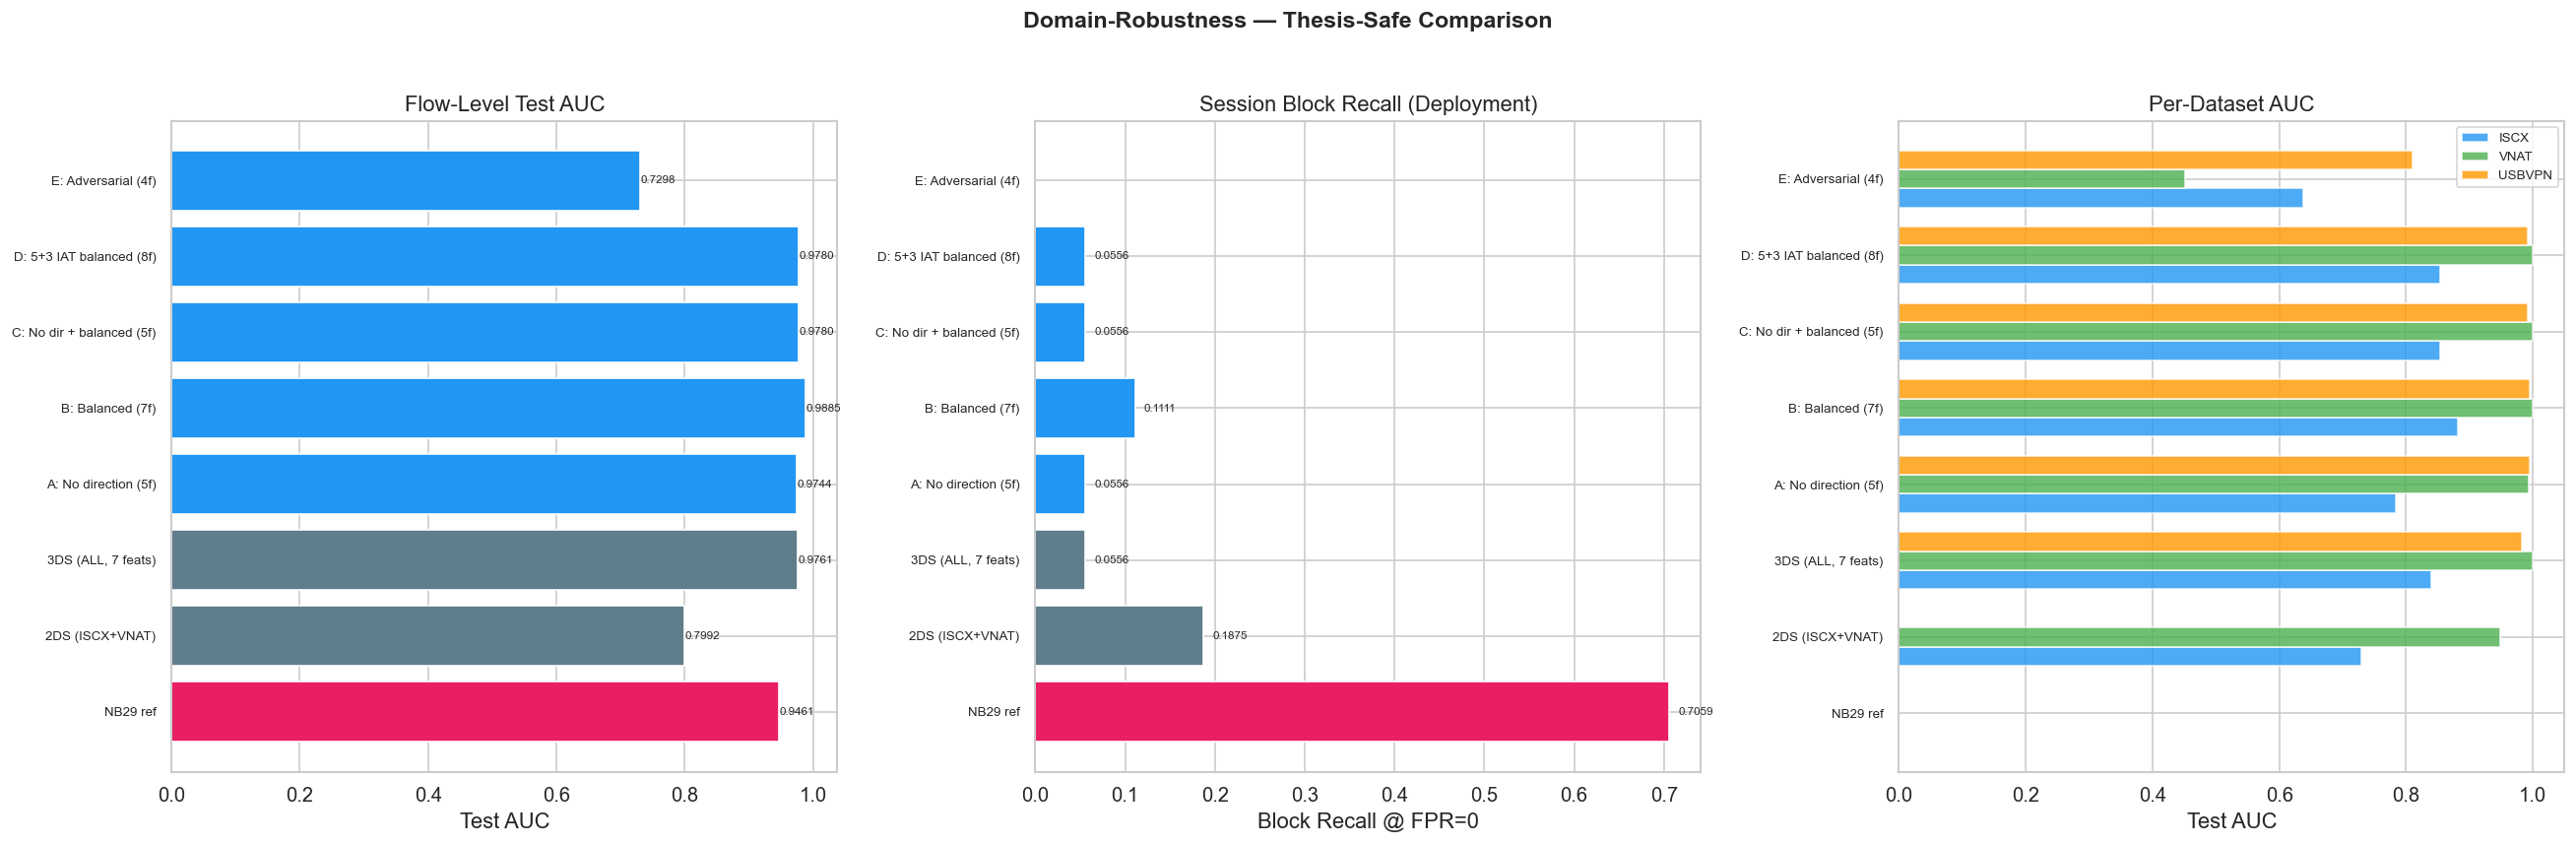

In [20]:
# ── Cell 19: Visualisation ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
labels = cmp_d['experiment'].tolist()
short = [l.replace('Baseline: ','').replace('NB29 VALIDATED (ref)','NB29 ref') for l in labels]
x = np.arange(len(short))
palette = ['#E91E63' if 'NB29' in l else '#607D8B' if 'Baseline' in l else '#2196F3' for l in labels]

ax = axes[0]
vals = cmp_d['test_auc'].fillna(0).values
ax.barh(x, vals, color=palette)
ax.set_yticks(x); ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel('Test AUC'); ax.set_title('Flow-Level Test AUC')
for i,v in enumerate(vals):
    if v>0: ax.text(v+.001, i, f'{v:.4f}', va='center', fontsize=7)

ax = axes[1]
if 'block_recall' in cmp_d:
    vals = cmp_d['block_recall'].fillna(0).values
    ax.barh(x, vals, color=palette)
    ax.set_yticks(x); ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel('Block Recall @ FPR=0'); ax.set_title('Session Block Recall (Deployment)')
    for i,v in enumerate(vals):
        if v>0: ax.text(v+.01, i, f'{v:.4f}', va='center', fontsize=7)

ax = axes[2]
bw = 0.25
for j,(ds,col) in enumerate([('iscx','#2196F3'),('vnat','#4CAF50'),('usbvpn','#FF9800')]):
    c = f'test_auc_{ds}'
    if c in cmp_d:
        ax.barh(x+j*bw, cmp_d[c].fillna(0).values, bw, label=ds.upper(), color=col, alpha=.8)
ax.set_yticks(x+bw); ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel('Test AUC'); ax.set_title('Per-Dataset AUC'); ax.legend(fontsize=8)

plt.suptitle('Domain-Robustness — Thesis-Safe Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Conclusion & Thesis-Safe Claims

### Valid claims after this notebook
1. Domain fingerprinting diagnostic quantifies feature leakage on intersection features
2. Dropping direction features reduces domain-detector AUC (but may hurt VPN signal)
3. Balanced sampling mitigates USBVPN dominance
4. IAT feature **reconstruction** from raw PCAP is methodologically safe (not imputation)
5. Session-level deployment metrics provide fair comparison with NB29

### Invalid claims (NOT established by this notebook)
1. "3-dataset beats 2-dataset" — unless session AUC + block recall match NB29
2. Any result using zero-filled structurally missing features
3. Threshold comparisons across different feature sets without re-calibration

### Deployment recommendation
The NB29 **2-dataset (ISCX+VNAT) validated candidate** remains the production
deployment unless a 3-dataset experiment achieves:
- Session AUC >= NB29 reference
- Block Recall @ FPR=0 >= NB29 reference
- Stable threshold (not dataset-dependent)

Any 3-dataset result below these is a **research finding only**.


In [21]:
# ── Cell 20: Automated conclusion ───────────────────────────────────────

print('='*72)
print('  DOMAIN-ROBUSTNESS EXPERIMENT SUMMARY')
print('='*72)

three_ds = [s for s in all_summaries
            if '2DS' not in s.get('experiment','') and 'SKIP' not in s.get('experiment','')]
valid_3 = [s for s in three_ds
           if isinstance(s.get('test_auc'),(int,float)) and not np.isnan(s['test_auc'])]

if valid_3 and nb29:
    best = max(valid_3, key=lambda s: s.get('session_roc_auc', s.get('test_auc', 0)))
    ref_a  = nb29.get('test_auc', 0)
    ref_sa = nb29.get('session_roc_auc', 0)
    ref_br = nb29.get('block_recall', 0)
    bst_sa = best.get('session_roc_auc', 0) or 0
    bst_br = best.get('block_recall', 0) or 0

    print(f'\n  NB29 ref:  flow AUC={ref_a:.4f}  session AUC={ref_sa:.4f}  block recall={ref_br:.4f}')
    print(f'  Best 3DS:  {best["experiment"]}')
    print(f'    flow AUC={best.get("test_auc",0):.4f}  session AUC={bst_sa:.4f}  block recall={bst_br:.4f}')

    ok = bst_sa >= ref_sa * 0.99 and bst_br >= ref_br * 0.95
    if ok:
        print('\n  -> DEPLOYMENT CANDIDATE: matches NB29 reference.')
        print('     Validate through run_firewall.py API before promoting.')
    else:
        print('\n  -> RESEARCH FINDING ONLY: does not match NB29 deployment metrics.')
        print('     Keep 2-dataset (ISCX+VNAT) as production deployment.')
        print('     These results inform thesis discussion on cross-domain challenges.')

full = {
    'experiments': all_summaries, 'nb29_reference': nb29,
    'diagnostic': {r['Feature Set']:r['Domain AUC'] for r in diag_results},
    'methodology': {'pool':'strict_feature_intersection',
                    'zero_fill':False, 'iat_reconstruction':'from_raw_pcap',
                    'session_eval':True},
}
with open(EXPERIMENTS_DIR / 'full_results.json', 'w') as f:
    json.dump(full, f, indent=2, default=str)
print(f'\nSaved to {EXPERIMENTS_DIR}')
print('='*72)


  DOMAIN-ROBUSTNESS EXPERIMENT SUMMARY

  NB29 ref:  flow AUC=0.9461  session AUC=0.9686  block recall=0.7059
  Best 3DS:  C: No dir + balanced (5f)
    flow AUC=0.9780  session AUC=0.9879  block recall=0.0556

  -> RESEARCH FINDING ONLY: does not match NB29 deployment metrics.
     Keep 2-dataset (ISCX+VNAT) as production deployment.
     These results inform thesis discussion on cross-domain challenges.

Saved to C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\experiments
